### Initialize instrumentation

In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, LeCroyScope
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
# set up readout and plotting
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
# open list of available instruments
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL11::INSTR', 'GPIB0::3::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [2]:
# connect to BNC 575 pulse generator (for controlling experimental time sequence)
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [5]:
# connect to WeederTech WTMCD-M driver (for 480 stepper motor)
weeder = Weeder.Weeder("ASRL1::INSTR")

In [6]:
# connect to MC USB-3114 (for compensation voltages)
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


### Set compensation voltages and define timing sequence

In [7]:
vset = np.array([0.1,-0.1,0.25])
mcbox.set_voltage_Nchan(channels = [0,1,6,7,10,11], voltages = [0,-vset[2],vset[1],-vset[1],vset[0],-vset[0]], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to -0.25 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 10 has been set to 0.1 V.
Channel 11 has been set to -0.1 V.
Voltages successfully set.


In [238]:
pulse_arrangement = [["A", 900e-6, 0, 2]]                   
T = 1000e-6

notes = {}

In [239]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
------------------------------------------------------------
[['A', 0.0009, 0, 2]]
------------------------------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 2.00

Output timers:
HGFEDCBA
00000001
------------------------------------------------------------


In [240]:
bnc575.start_pulses()

In [300]:
# partial sequence with blue excitation light only
pulse_arrangement = [["A", 900e-6, 0, 2, 1],                    # MOT
                     [["B", 5e-6, 8e-6, 2, 1],                   # 780
                     ["C", 5e-6, 8e-6, 6, -1]],            # 480 EXC
                     ["E", 26e-6, 0, 8, 1],                   # DEI switch/photon counter
                    ]

T = 1100e-6
#cycle_number = 30

# photon counter gate width and delay
#gate_width = 20e-6
#gate_delay = 3e-6

# stepper motor slope (for blue laser)
#freq_factor = 129 * 2 # kHz

#notes = {"gate_width": gate_width, "gate_delay": gate_delay}
notes = {}

In [302]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.10e-03s
Pulses number: N/A
------------------------------------------------------------
[['A', 0.0009, 0, 2, 1], ['B', 5e-06, 0.000908, 2, 1], ['C', 5e-06, 0.000908, 6, -1], ['E', 2.6e-05, 0.000913, 8, 1]]
------------------------------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 2.00

Output timers:
HGFEDCBA
00000001
------------------------------------------------------------
------------------------------------------------------------
The channel B is set to:
Width: 5.0000e-06s
Delay: 9.0800e-04s
Synchronize to: T0
Out: 2.00

Output timers:
HGFEDCBA
00000010
------------------------------------------------------------
------------------------------------------------------------
The channel C is set to:
Width: 5.0000e-06s
Delay: 9.0800e-04s
Synchronize to: T0
Out: 6.00

Output timers:
HGFEDCBA
00000100
-

In [303]:
bnc575.start_pulses()

### Find the Rydberg resonance

In [9]:
# find current stepper motor position
weeder.position(header = "A", query = True)

'A6000'

In [305]:
# begin stepper motor at initial position 6000, then move it out to increase the laser frequency
weeder.move("A", position = 6000, progress = True)

start at 7790 --> 6000.0 --> 6000
Old position: 7790
New position: 6000


In [294]:
# used to move motor incrementally to zero in on the location of a resonance
weeder.advance(header = "A", num_step = 10)

start at 7780 --> 7790.0 --> 7790
Old position: 7780
New position: 7790


### Collect oscilloscope traces

*IDN -> LECROY,9354AM,935403739,08.2.1



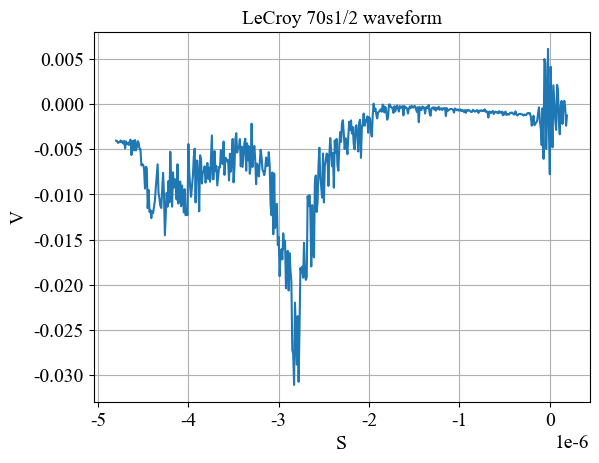

In [304]:
# connect to LeCroy 9354AM oscilloscope (for displaying DEI pulse and Rydberg counts for both states)
lecroy = LeCroyScope.LeCroyScope('GPIB0::3::INSTR', timeout = 20000)
lecroy.setup_transfer()
t, v70s, info = lecroy.read_waveform("TA")
tgate, vgate, info = lecroy.read_waveform("C2")
plt.plot(t, v70s)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("LeCroy 70s1/2 waveform")
plt.grid(True)
plt.show()
lecroy.close()

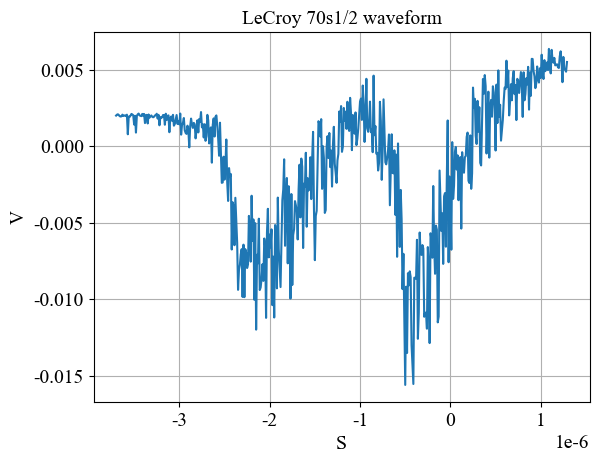

In [176]:

plt.plot(t, v70s)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("LeCroy 70s1/2 waveform")
plt.grid(True)
plt.show()





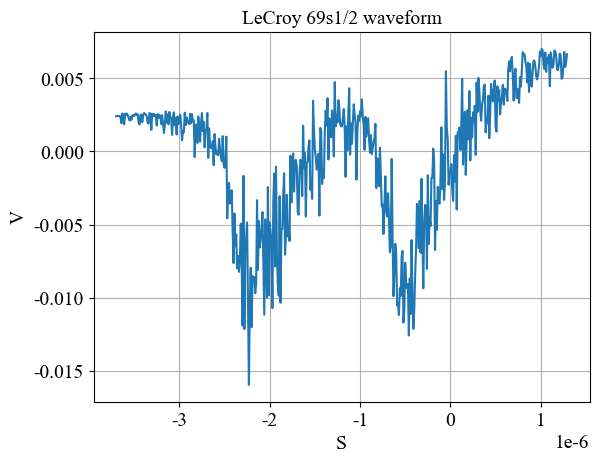

In [177]:

plt.plot(t, v69s)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("LeCroy 69s1/2 waveform")
plt.grid(True)
plt.show()

In [ ]:

plt.plot(t, vgate)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("LeCroy DEI waveform")
plt.grid(True)
plt.show()

Text(0, 0.5, 'voltage')

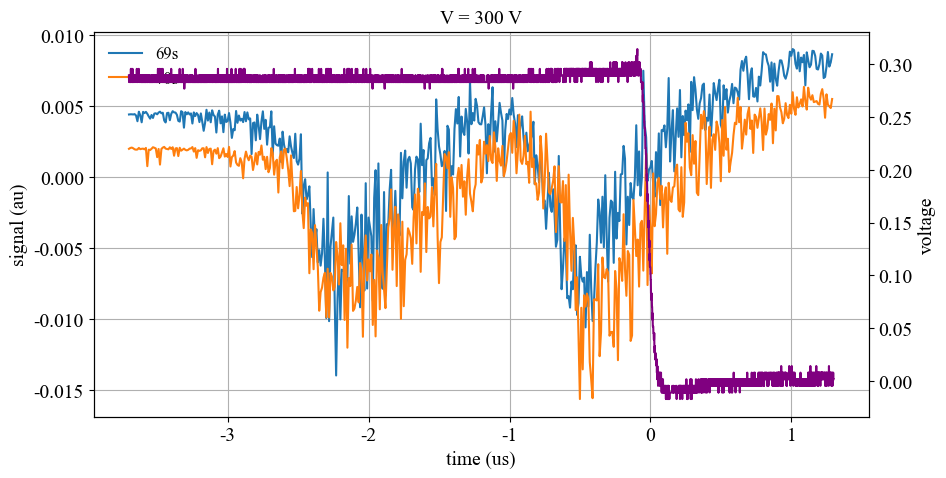

In [178]:
fig, ax_count = plt.subplots(figsize = (10,5))
ax_gate = ax_count.twinx()

ax_count.plot(t*1e6, v69s+0.002, label = "69s")
ax_count.plot(t*1e6, v70s, label = "70s")
ax_count.set_xlabel("time (us)")
ax_count.set_ylabel("signal (au)")
ax_count.legend()
ax_count.set_title("V = 300 V")
ax_count.grid()

ax_gate.plot(tgate*1e6, vgate, c = "purple")
ax_gate.set_ylabel("voltage")

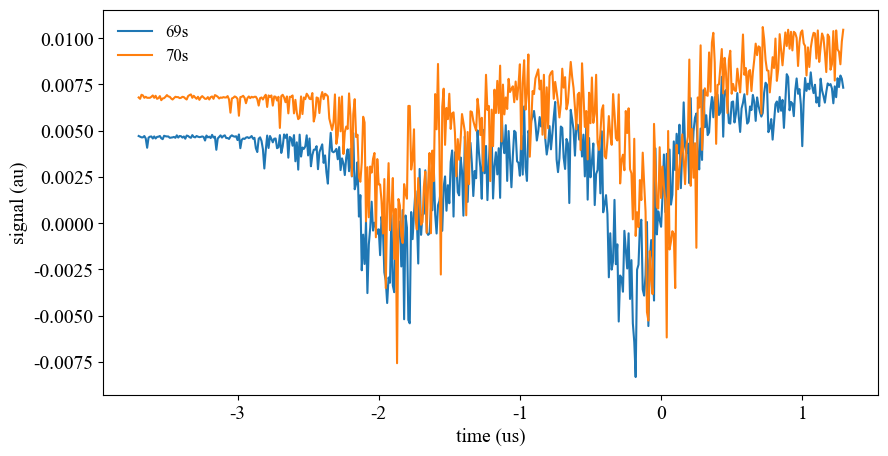

In [169]:
fig, ax_count = plt.subplots(figsize = (10,5))
# ax_gate = ax_count.twinx()
length = len(t)

ax_count.plot(t*1e6, v69s+0.002, label = "69s")
ax_count.plot(t*1e6, v70s*1.5, label = "70s")
ax_count.set_xlabel("time (us)")
ax_count.set_ylabel("signal (au)")
ax_count.legend()

### Shut down instrumentation

In [ ]:
# reset voltages to zero
vset = np.array([0.0,0.0,0.0])
mcbox.set_voltage_Nchan(channels = [0,1,6,7,10,11], voltages = [0,-vset[2],vset[1],-vset[1],vset[0],-vset[0]], bipolar = True)

In [ ]:
# save current stepper motor position
weeder.save(header = "A", query = True)

In [ ]:
# OPTIONAL: disables pulses from BNC box (can also be done by pressing RUN/STOP button or individual channel buttons on device)
bnc575.disable_all()

In [ ]:
# OPTIONAL: disarms the pulse generator (can also be done by pressing RUN/STOP button on device)
bnc575.disarm_all()

In [ ]:
# disconnect from pulse generator
bnc575.pyvisa.close()